# Linear memory from phenomelogical models

As proposed by Lopez et al. (https://arxiv.org/html/2305.04761v3) or by Favata (https://www.phy.olemiss.edu/StronGBaD/talks/Favata.pdf), the time evolution of the linear memory from the ejecta can be `phenomenologically` modeled using either an exponential or a hyperbolic tangent function. In this notebook, we compare these models and introduce the contribution of the 2 ejecta components (dynamical and wind).

## General function to plot the models

In [1]:
import utils_phenom as up
import utils_signal as using
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI


/home/pycbc/work/Memory_Lopez/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


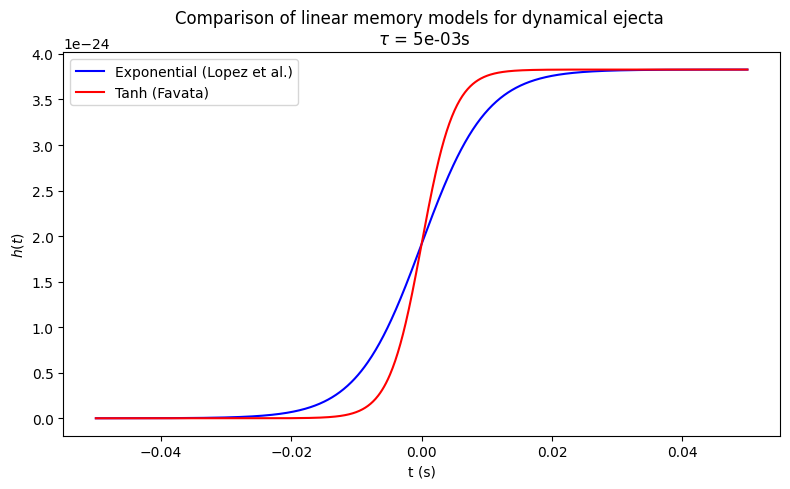

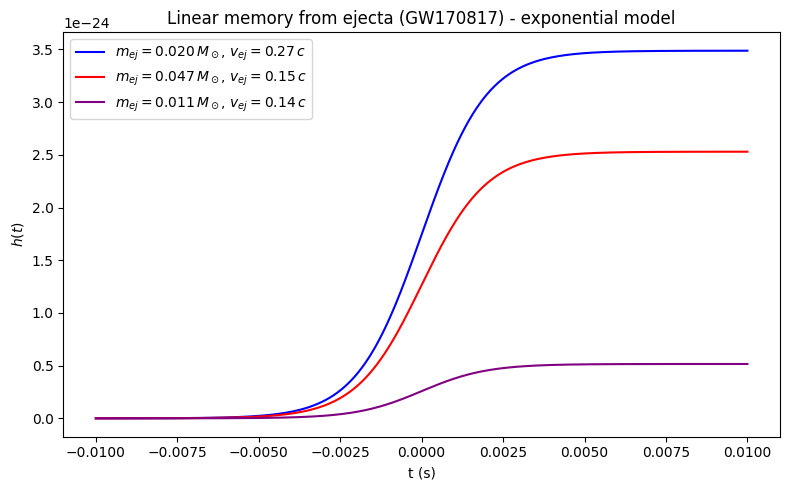

In [2]:
# 1. Plot for typical dynamical ejecta (Lopez vs Favata)
tau = 5e-3  # s
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2   # m/s
r = 40e6  # Mparsecs
t = np.linspace(-0.05, 0.05, 1000)

# Exponential model
_, h_lopez = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='exponential', plot=0)
# Tanh model
_, h_favata = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='tanh', plot=0)

plt.figure(figsize=(8, 5))
plt.plot(t, h_lopez, label='Exponential (Lopez et al.)', color='blue')
plt.plot(t, h_favata, label='Tanh (Favata)', color='red')
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title(f"Comparison of linear memory models for dynamical ejecta \n $\\tau$ = {tau:.0e}s")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot for GW170817 ejecta components (Lopez model)
M_ej_arr = np.array([0.02, 0.047, 0.011])  # solar masses
v_ej_arr = np.array([0.27, 0.15, 0.14])   # m/s
r_gw = 40e6  # parsecs
tau_gw = 0.001  # s
t_gw = np.linspace(-0.01, 0.01, 1000)
colors = ['blue', 'red', 'purple']

plt.figure(figsize=(8, 5))
for i in range(3):
    _, h = up.phenom_memory_models(tau_gw, M_ej_arr[i], v_ej_arr[i], r_gw, t_gw, model='exponential', plot=False)
    plt.plot(t_gw, h, color=colors[i],
             label=f"$m_{{ej}}={M_ej_arr[i]:.3f}\\,M_\\odot$, $v_{{ej}}={v_ej_arr[i]:.2f}\\,c$")
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title("Linear memory from ejecta (GW170817) - exponential model")
plt.legend()
plt.tight_layout()
plt.show()

## Plot of the dynamical, wind and total memory for a given model

To be more physcially motivated, we can apply masks to the memory evolution, so that the memory grows only during the time of activity of each ejecta component. After the end of the activity, the memory remains constant. This is done in the function `linear_memory_ejecta_masked` defined in `utils_phenom.py`. Based on the Table 1 of https://arxiv.org/pdf/1912.05659, the typical time of activity of each ejecta component is given by the following ranges:
- Dynamical ejecta: 0 to 10 ms with a caracteristic timescale of 1 ms
- Wind ejecta: 10 ms to 10 s with a caracteristic timescale of 1 s

/home/pycbc/work/Memory_Lopez/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return delta_h / (1 + np.exp(-t / tau))


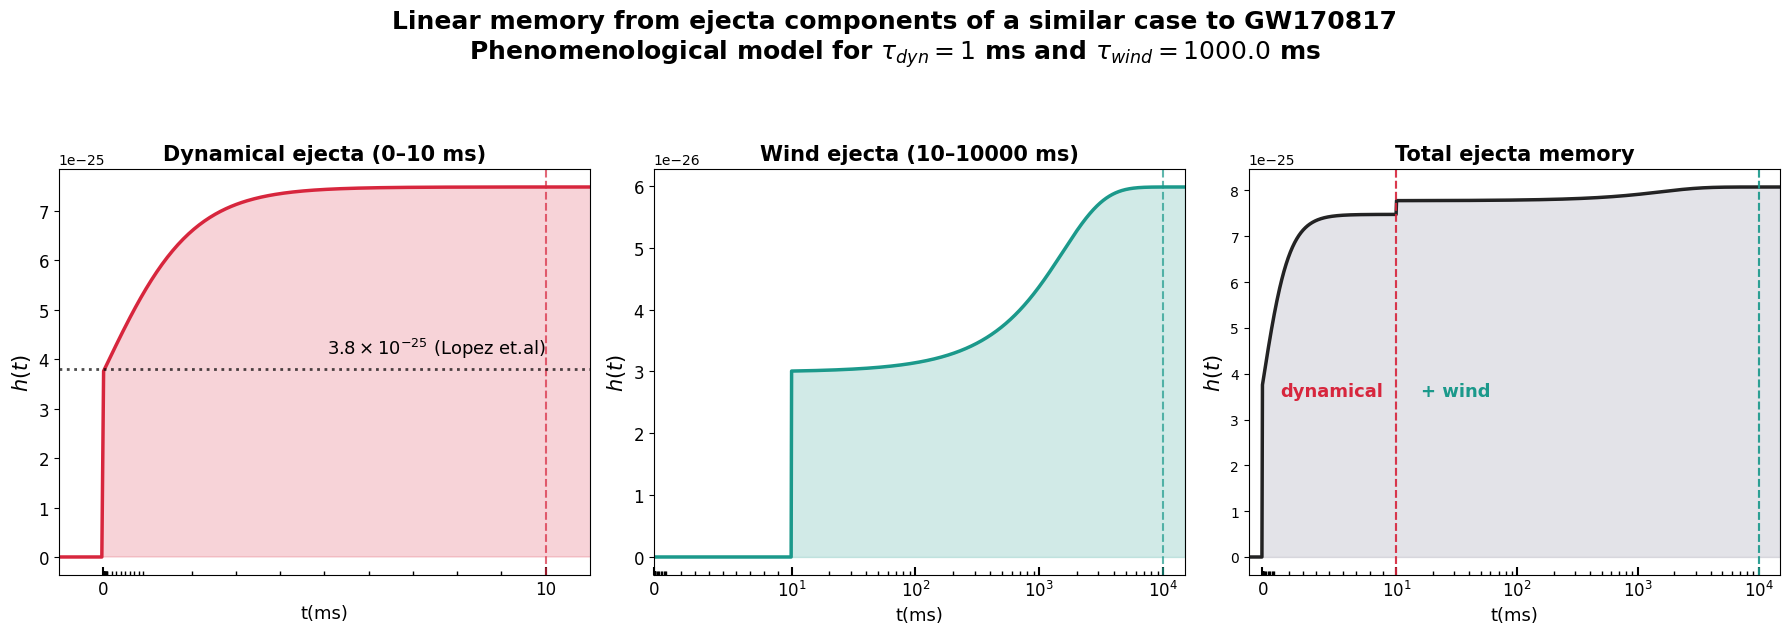

In [3]:
# Parameters 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1  

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3  

r = 40  * 1e6  
t = np.linspace(-5., 15., 500000) * 1e3  # ms

# Physically motivated time ranges for the activity of each ejecta component (to be modified according to the simulations and assumptions: EOS, mass ratio, etc)
start_dyn, end_dyn = 0, 10 
start_wind, end_wind = 10, 10e3 
up.phenom_memory_ejecta_components(
    t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    r, model='exponential', plot=True
)

### Comparison of the different caracteristic timescales for each ejecta component

Now we can determined how the caracteristic timescale of each ejecta component impact the total memory evolution :

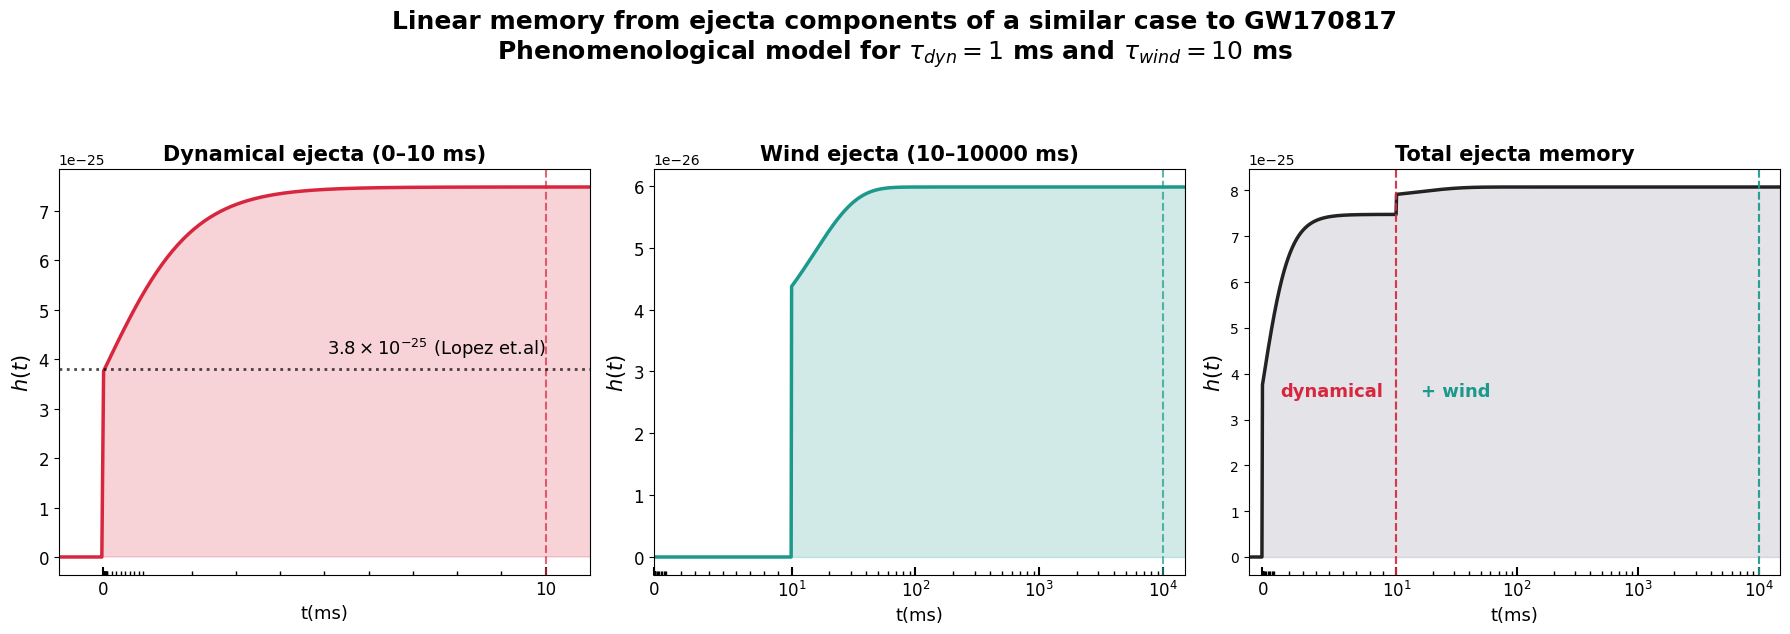

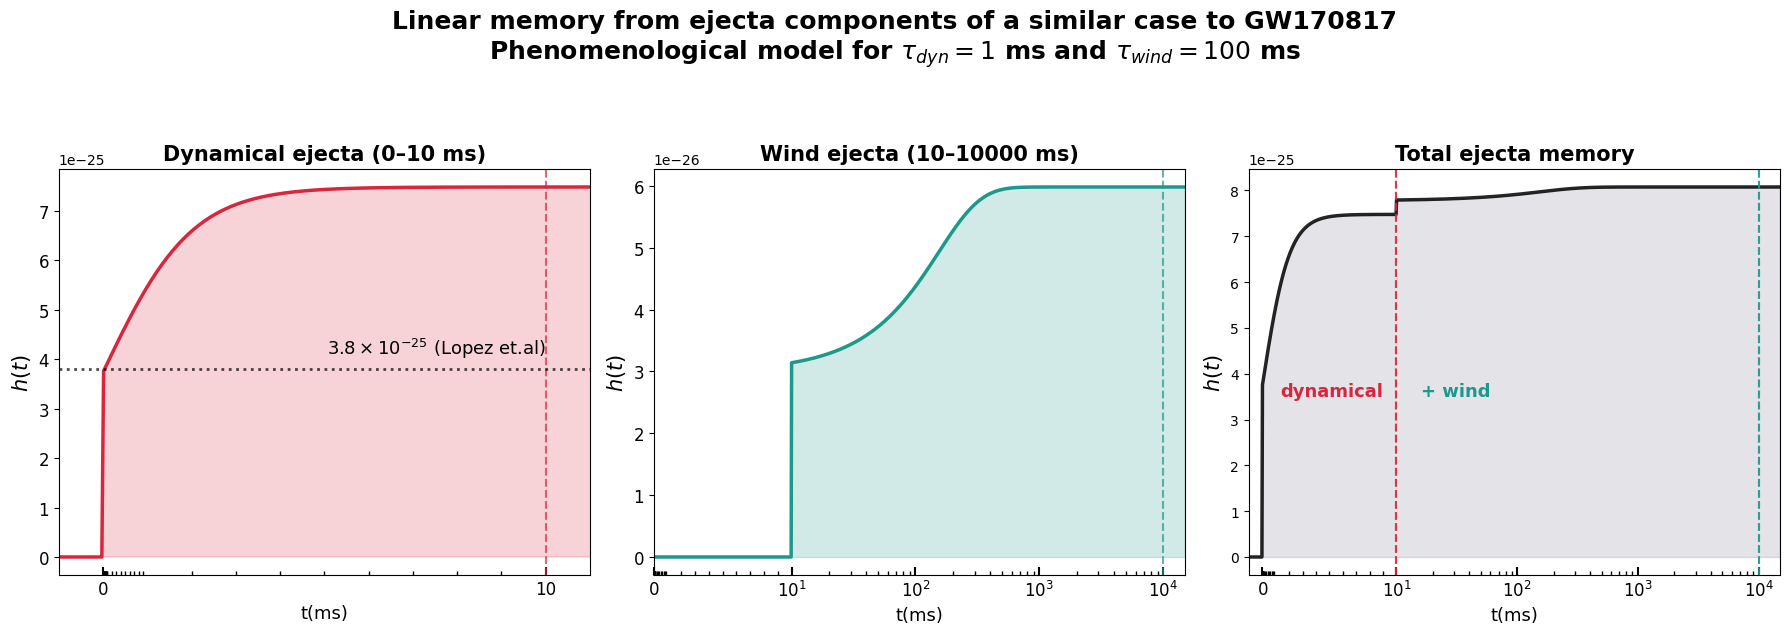

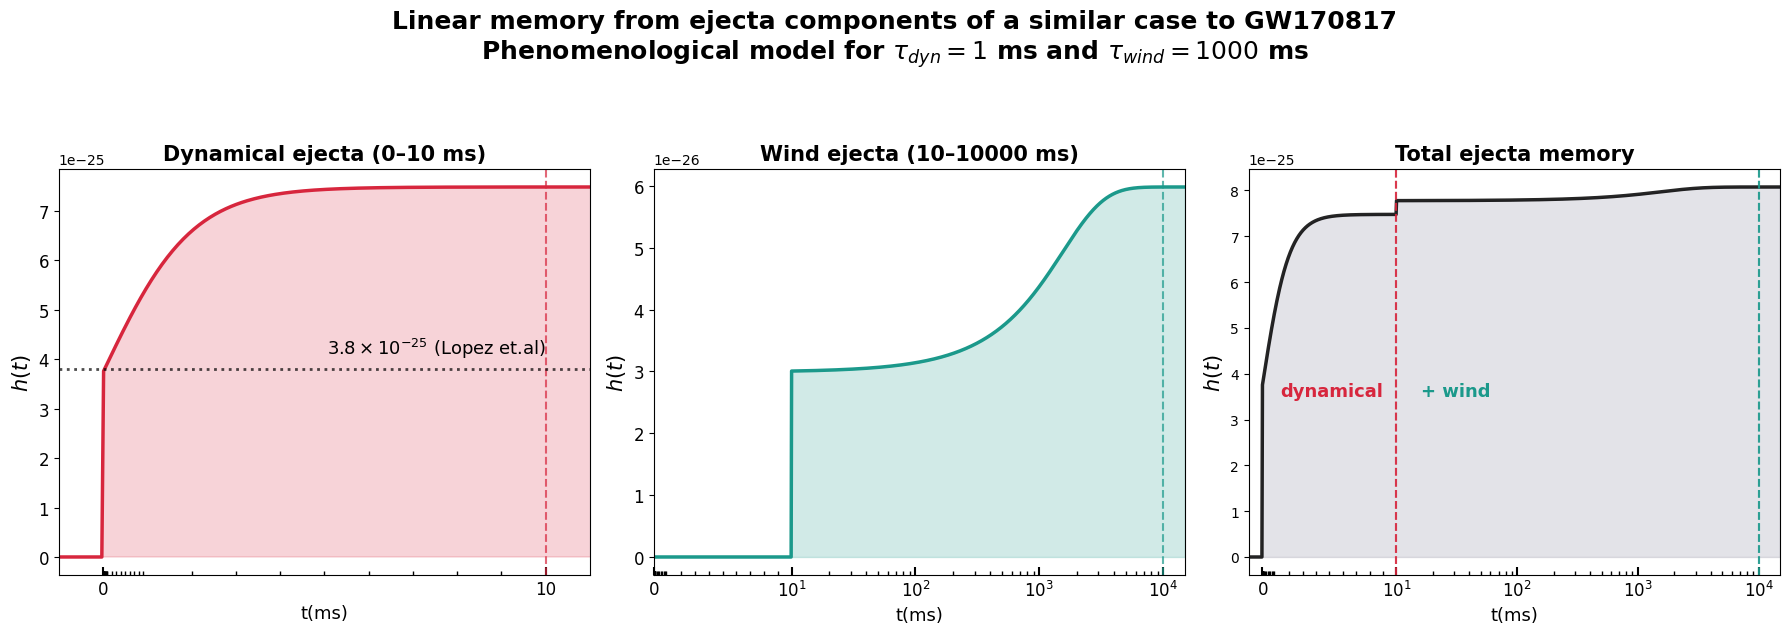

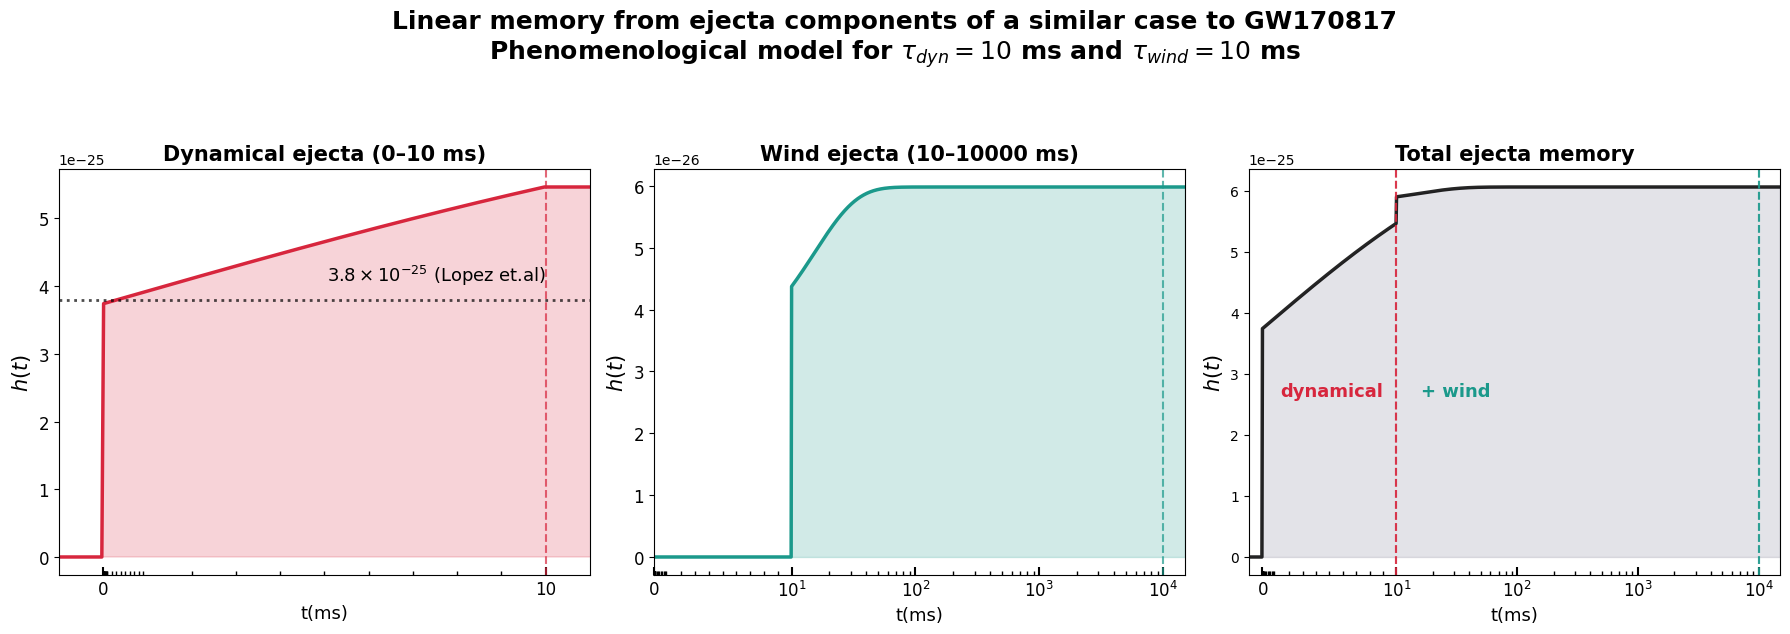

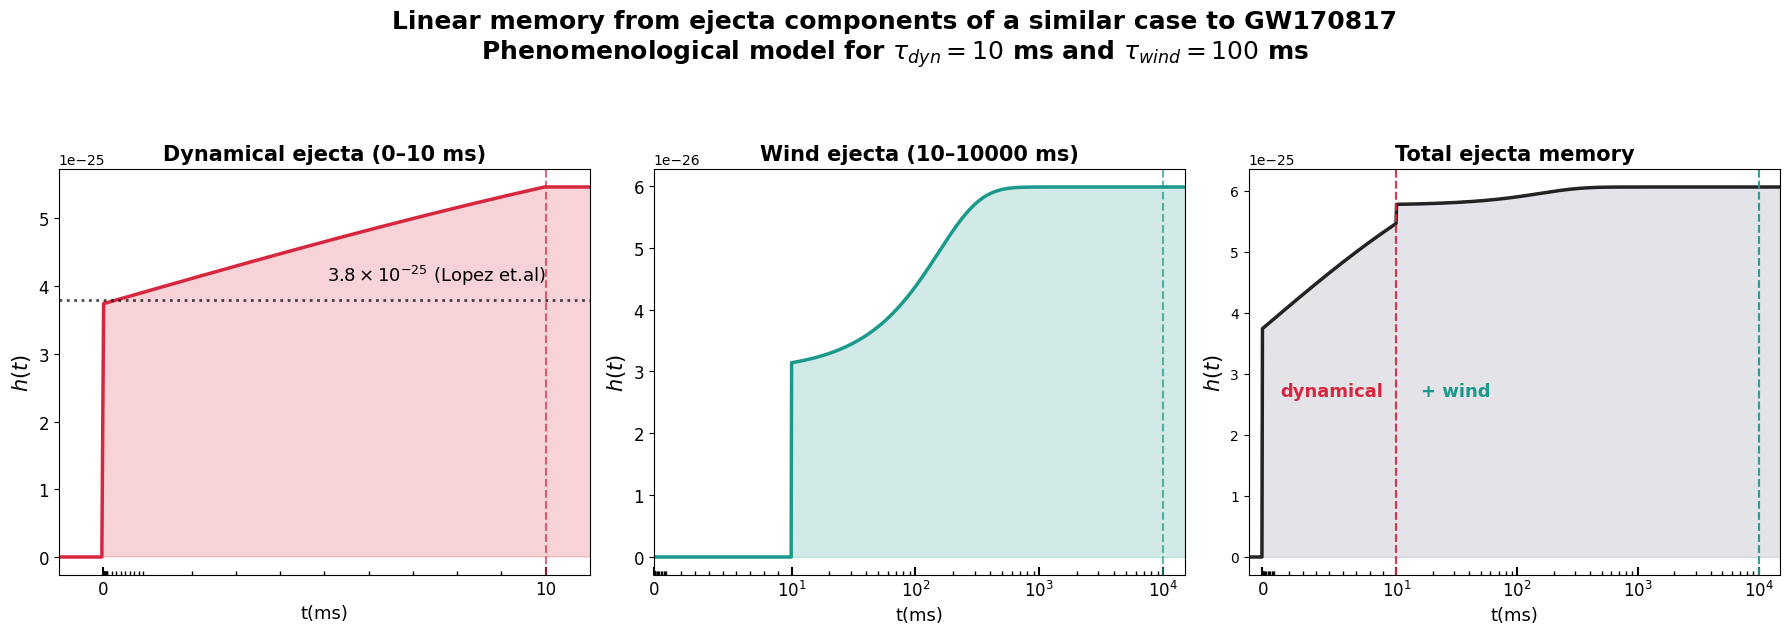

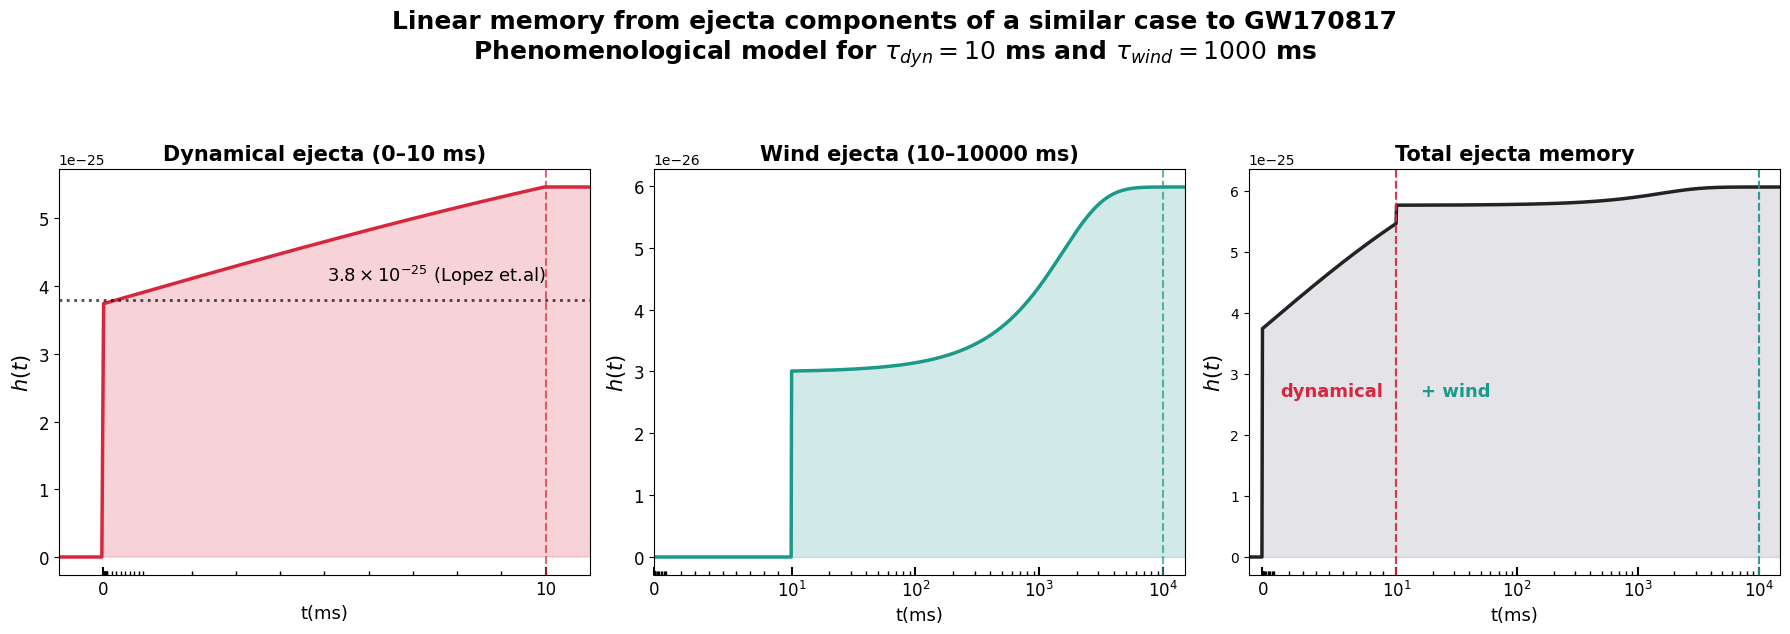

In [4]:
tau_dyn_ms = [1, 10] 
tau_wind_ms = [10,100, 1000] 
for tau_dyn in tau_dyn_ms:
    for tau_wind in tau_wind_ms:
        up.phenom_memory_ejecta_components(
            t, M_ej_dyn, v_ej_dyn, tau_dyn, start_dyn, end_dyn,
            M_ej_wind, v_ej_wind, tau_wind, start_wind, end_wind,
            r, model='exponential', plot=True
        ) 

GRB memory

A GRB can produce a memory signal that dependends on the release of energy $E_j$ in accelerating jets (forward and backward) with ultrarelativistic velocities. If we denode by $\beta\sim 1$ the velocity of the jets and by $\theta$ the angle between the jet axis and the line of sight, the memory signal can be estimated as  : 
$$\Delta h = \frac{2 E_j \beta^2}{r} \frac{\sin^2\theta}{1-\beta\cos\theta}$$

And it is estimated to have a caracteristic timescale of $\tau_{GRB} \sim 0.2 - 3$ ms (source ? https://arxiv.org/pdf/1201.4431 - conclusion a.), depending on the opening angle and composition of the jet(Lopez et al.). We can then apply the same phenomenological model as for the ejecta, but with this new timescale and a different amplitude. We can also add this contribution to the total memory from the ejecta. For the case of GRB170817A, the energy released in the jet is estimated to be $E_j \sim 10^{47}$ erg, which is much lower than the typical energy released in a GRB ($\sim 10^{51}$ erg). This is because GRB170817A was observed off-axis, with an angle of $\theta \sim 30$ degrees. The associated GRB is denoted as a sGRB, lasting ~2 s. 

Does the factor 2 is related to the fact that there are 2 jets (forward and backward) ?

I added a factor of $G/c^4$ in front of $\Delta h$ to make the amplitude of the GRB an adimensional strain.

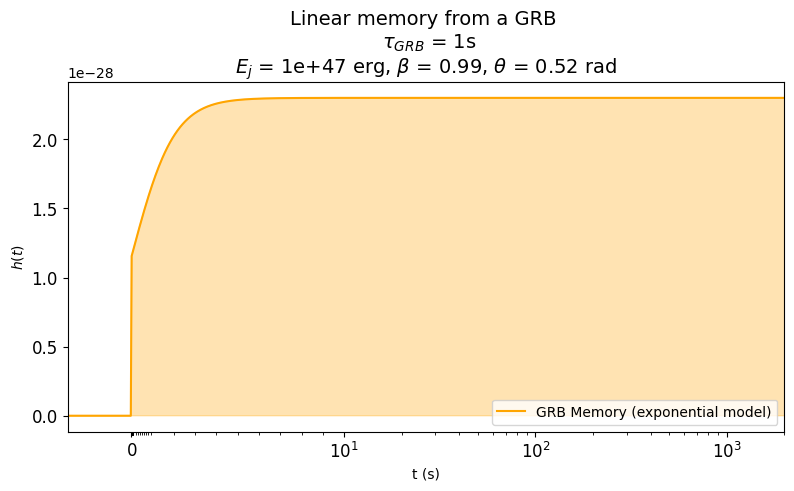

In [5]:
# Parameters for GRB memory
E_erg = 1e47  # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
r = 40  * 1e6  # parsecs
t = np.linspace(-5., 15., 500000) * 1e3  # ms
start_GRB, end_GRB = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
_= up.phenom_memory_GRB(t, E_erg, beta, theta, r, tau_grb_ms, start_GRB, end_GRB, model='exponential', plot=True)


We observe that the GRB memory has a **higher** amplitude than the ejecta memory, but a much shorter timescale. The total memory signal would then be dominated by the GRB contribution at early times, and by the ejecta contribution at later times.

The dependence in the angle $\theta$ is quite strong, so if the jet is not pointed towards us, the memory signal would be much weaker : 

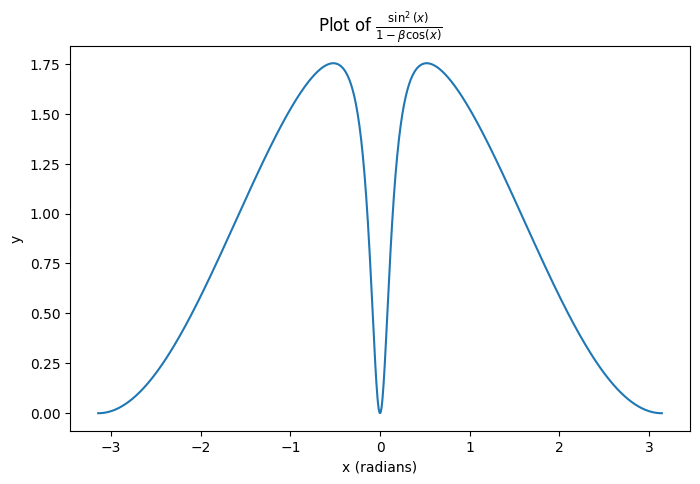

In [6]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)**2/ (1 - 0.99* np.cos(x))

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("x (radians)")
plt.ylabel("y")
plt.title(r"Plot of $\frac{\sin^2(x)}{1- \beta \cos(x)}$")
plt.show()

Add the GRB memory to the total memory from the ejecta (dynamical + wind + GRB)

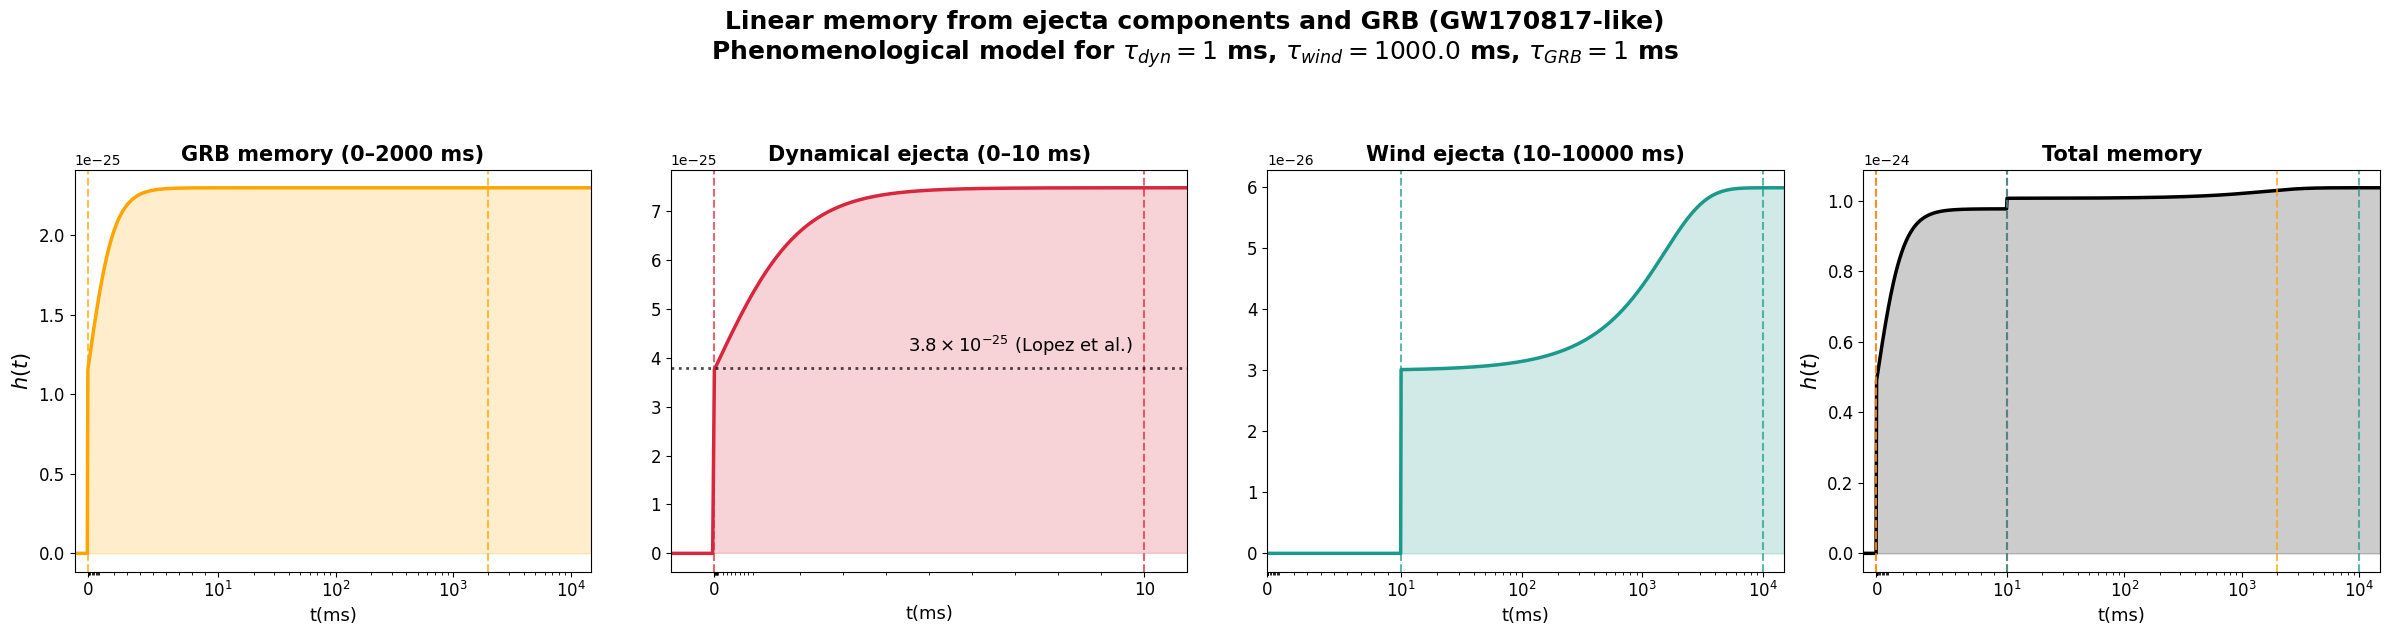

In [7]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1 

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 40  * 1e6  # 170817
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3

up.phenom_memory_ejecta_components_GRB(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb
)

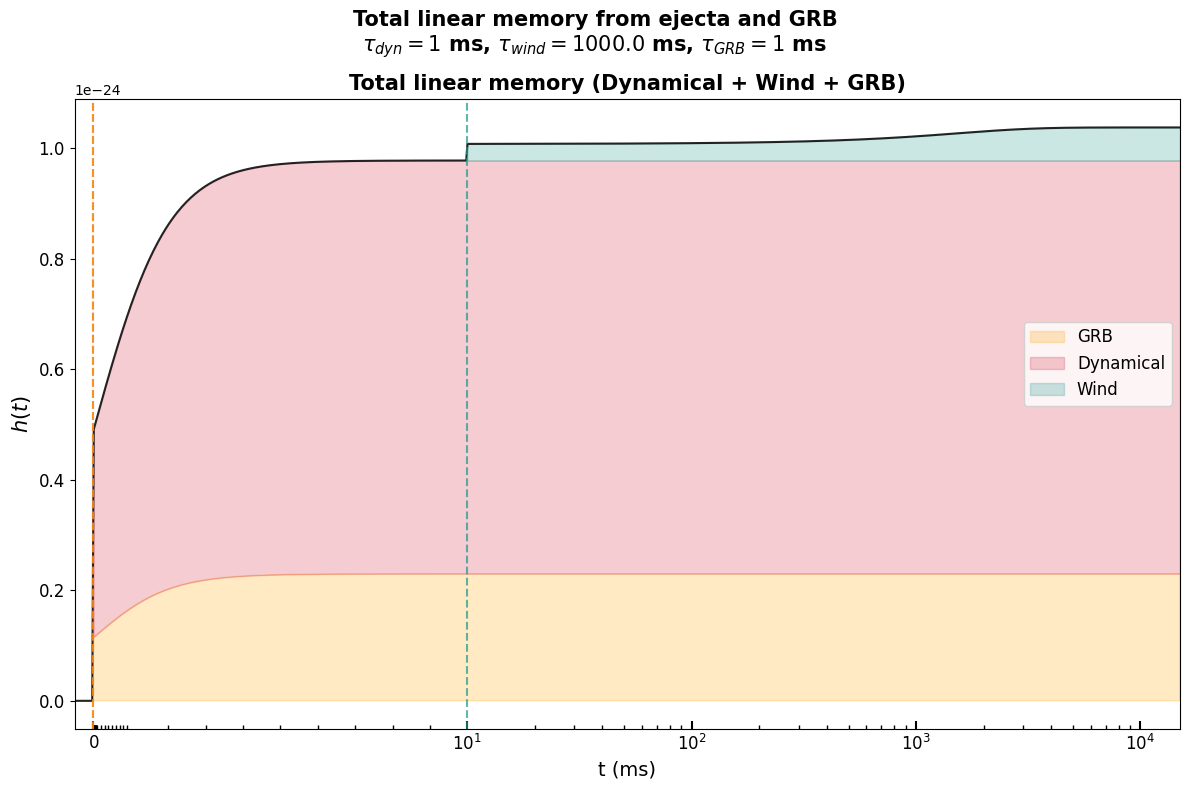

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.03750085e-24, 1.03750085e-24, 1.03750085e-24])

In [8]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 40  * 1e6  # 170817
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
up.phenom_memory_total_plot(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb
)

Test BOAT

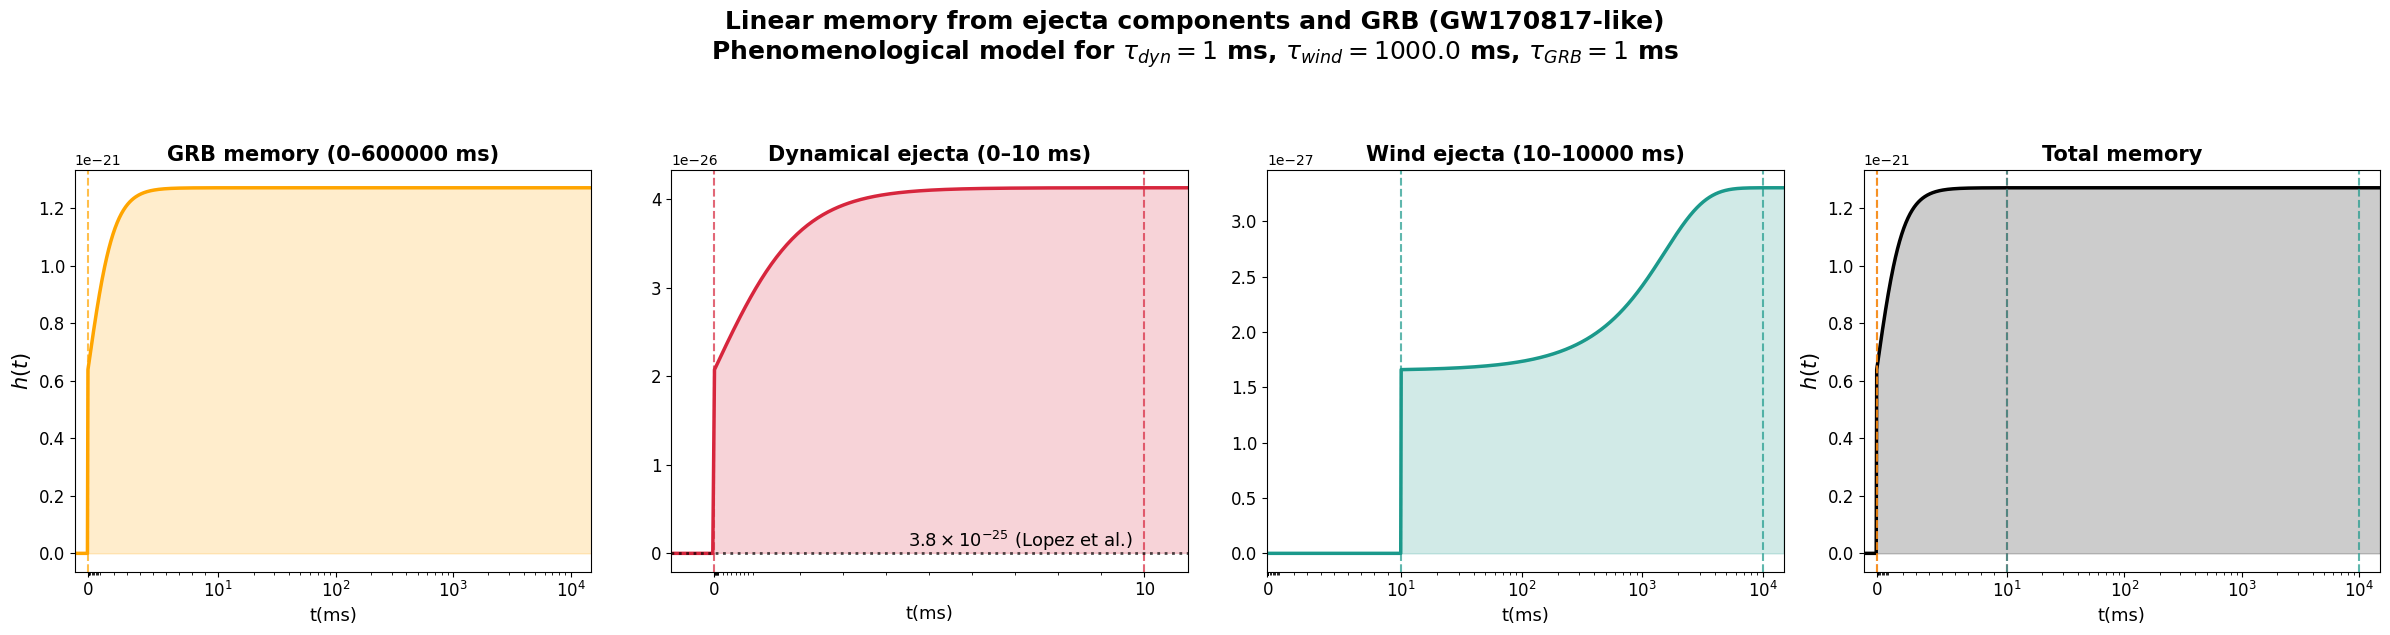

In [9]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1 

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 724  * 1e6  #BOAT
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3

up.phenom_memory_ejecta_components_GRB(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    delta_h_typical=0
)

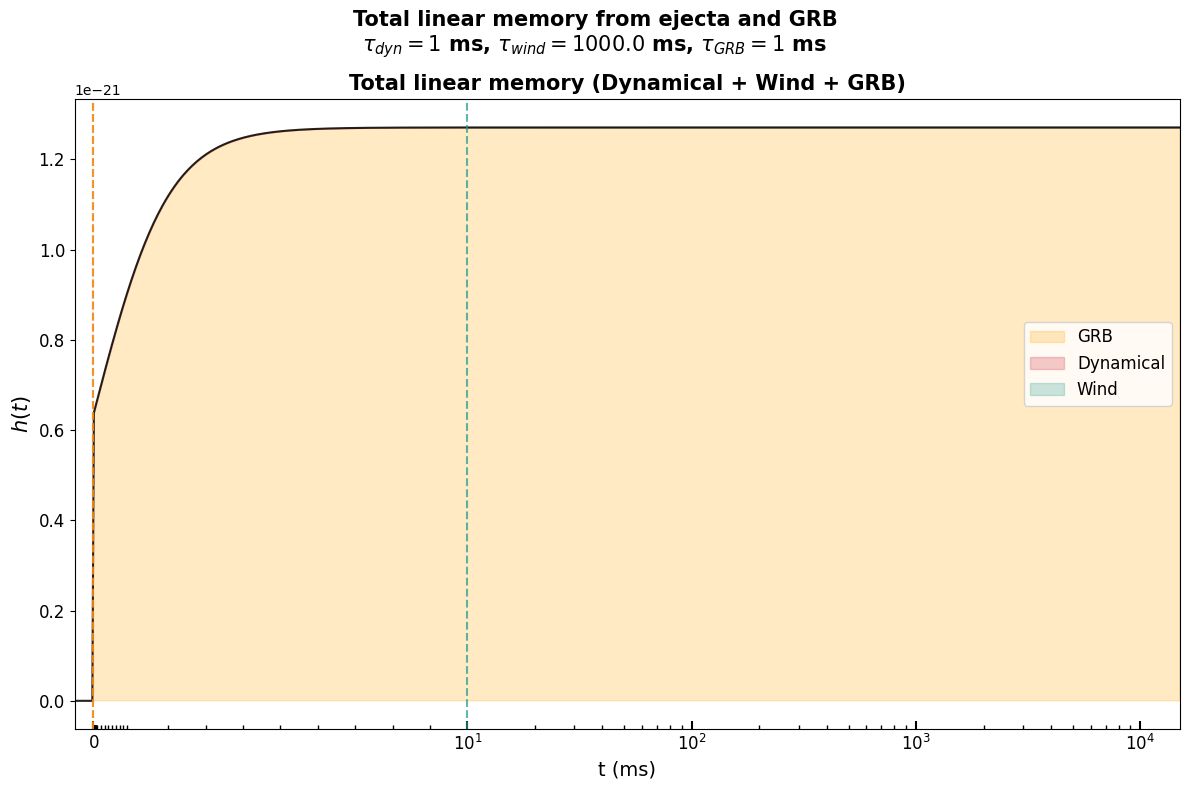

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.27076075e-21, 1.27076075e-21, 1.27076075e-21])

In [10]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r_BOAT = 724 * 1e6  # BOAT
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
up.phenom_memory_total_plot(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb
)

## Test with different parameters for the GRB memory

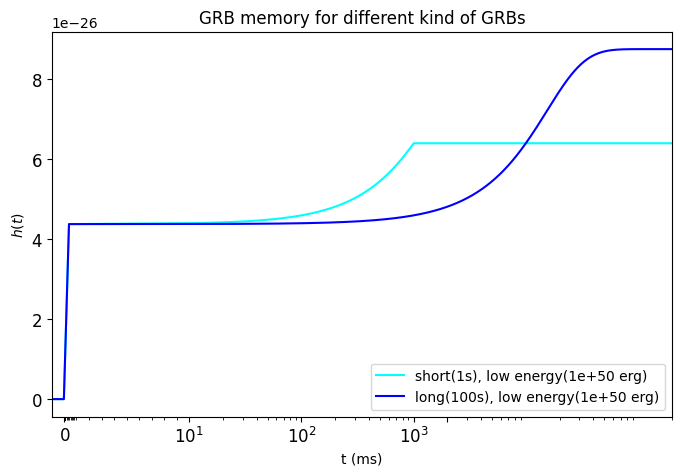

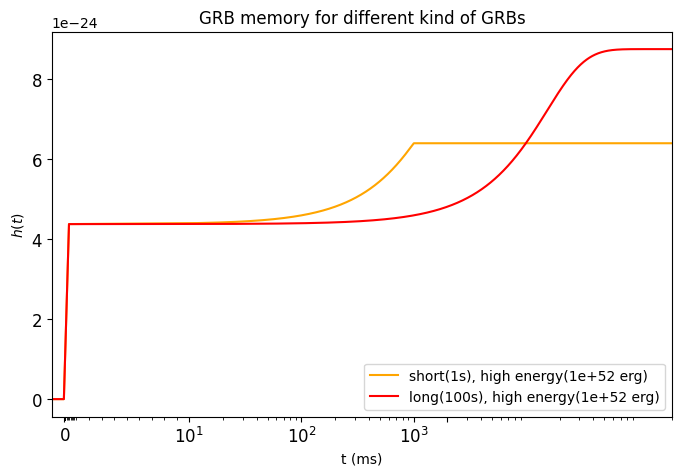

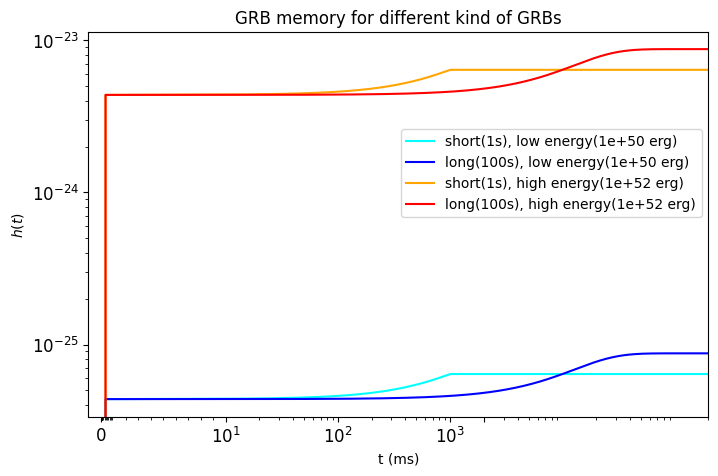

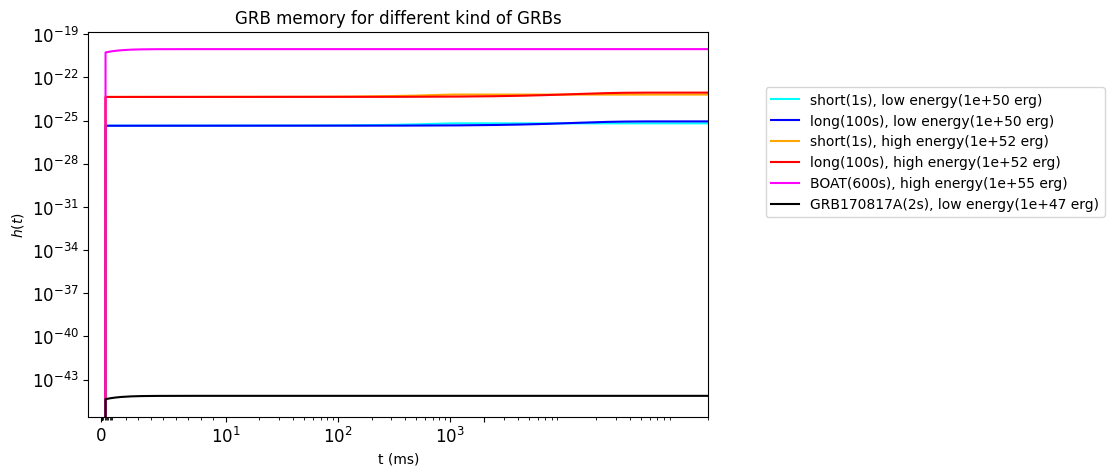

In [11]:
from matplotlib.ticker import FixedLocator, LogLocator
# test for a short low energetic GRB, short and higly energetic GRB, and a long GRB with low and high energy
# we test 4 cases 
t = np.linspace(-5., 200., 500000) * 1e3  # ms
r = 100 * 1e6  # 100 Mpc
# short : 1s -- long: 100s
end_grb = np.array([1, 100]) * 1e3 # s
# low energy: 1e49 erg -- high energy: 1e52 erg
energy = np.array([1e50, 1e52])  # erg
theta = np.deg2rad(45)  # 45 degrees off axis - tradeoff between detectability and rate
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = np.array([1, 10]) *1e3  # s
start_grb = 0
h_grb = []
cases =[
    {"energy": energy[0], "end_grb": end_grb[0], "label": "short" + f'({end_grb[0]/1000:.0f}s)'+", low energy"+ f'({energy[0]:.0e} erg)', 'color': 'cyan'},
    {"energy": energy[0], "end_grb": end_grb[1], "label": "long" + f'({end_grb[1]/1000:.0f}s)'+", low energy"+ f'({energy[0]:.0e} erg)', 'color': 'blue'},
    {"energy": energy[1], "end_grb": end_grb[0], "label": "short" + f'({end_grb[0]/1000:.0f}s)'+", high energy"+ f'({energy[1]:.0e} erg)', 'color': 'orange'},
    {"energy": energy[1], "end_grb": end_grb[1], "label": "long" + f'({end_grb[1]/1000:.0f}s)'+", high energy"+ f'({energy[1]:.0e} erg)', 'color': 'red'},
]
for e in energy:
    for end, tau in zip(end_grb, tau_grb_ms):
        h_grb.append(up.phenom_memory_GRB(
            t, e, beta, theta, r, tau, start_grb, end, model='exponential', plot=False))
        
# BOAT case 
E_j_boat = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta_boat = np.deg2rad(30)  # 30 degrees off axis
beta_boat = 0.99  # ultrarelativistic jet
tau_grb_boat_ms = 1  # ms
start_grb_boat, end_grb_boat = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
h_boat = up.phenom_memory_GRB(
    t, E_j_boat, beta_boat, theta_boat, r, tau_grb_boat_ms, start_grb_boat, end_grb_boat, model='exponential', plot=False)
# Plot short GRBs (1s, low and high energy)

# 170817 case
E_j_170817 = 1e47   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta_170817 = np.deg2rad(30)  # 30 degrees off axis
beta_170817 = 0.99  # ultrarelativistic jet
tau_grb_170817_ms = 1  # ms
start_grb_170817, end_grb_170817 = 0, 2000
r_170817 = 40 * PC_SI * 1e6  # 170817
h_170817 = up.phenom_memory_GRB(
    t, E_j_170817, beta_170817, theta_170817, r_170817, tau_grb_170817_ms, start_grb_170817, end_grb_170817, model='exponential', plot=False)

plt.figure(figsize=(8, 5))
for i in [0,1]:  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right")
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()

plt.figure(figsize=(8, 5))
for i in [2,3]:  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right")
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()


plt.figure(figsize=(8, 5))
for i in range(4):  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right", bbox_to_anchor=(1.0, 0.5))
plt.yscale('log')
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)
from matplotlib.ticker import FixedLocator, LogLocator
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()

plt.figure(figsize=(8, 5))
for i in range(4):  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.plot(t, h_boat, label='BOAT' + f'({end_grb_boat/1000:.0f}s)'+", high energy"+ f'({E_j_boat:.0e} erg)', color='magenta')
plt.plot(t, h_170817, label='GRB170817A' + f'({end_grb_170817/1000:.0f}s)'+", low energy"+ f'({E_j_170817:.0e} erg)', color='black')
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right", bbox_to_anchor=(1.65, 0.5))
plt.yscale('log')
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)
from matplotlib.ticker import FixedLocator, LogLocator
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()



## FFT of the different memory contributions

In [12]:
# BOAT case : 
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j_boat = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta_boat = np.deg2rad(30)  # 30 degrees off axis
beta_boat = 0.99  # ultrarelativistic jet
tau_grb_boat_ms = 1  # ms
r_boat = 724 * 1e6  # BOAT
start_grb_boat, end_grb_boat = 0, 600*1e3 # end GRB at 600s 

h_BOAT = up.phenom_memory_GRB(
    t, E_j_boat, beta_boat, theta_boat, r_boat, tau_grb_boat_ms, start_grb_boat, end_grb_boat, model='exponential', plot=False)

In [13]:
# GW170817 case
E_j_170817 = 1e47   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta_170817 = np.deg2rad(30)  # 30 degrees off axis
beta_170817 = 0.99  # ultrarelativistic jet
tau_grb_170817_ms = 1  # ms
start_grb_170817, end_grb_170817 = 0, 2000
r_170817 = 40 * 1e6 

# Ejecta parameters for GW170817
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2   # m/s
tau_dyn_ms = 1  # ms

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
h_170817_grb = up.phenom_memory_GRB(
    t, E_j_170817, beta_170817, theta_170817, r_170817, tau_grb_170817_ms,
    start_grb_170817, end_grb_170817, model='exponential', plot=False)
h_170817_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn,tau_dyn_ms, r_170817, start_dyn, end_dyn, model='exponential')
h_170817_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_ms, r_170817, start_wind, end_wind, model='exponential')
h_170817_total = h_170817_grb + h_170817_dyn + h_170817_wind


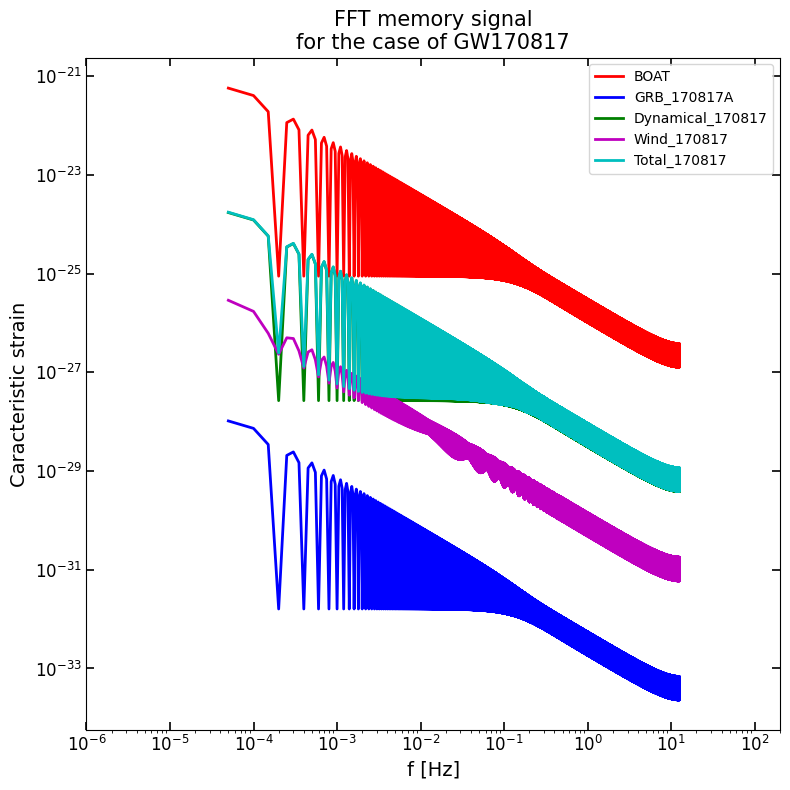

In [14]:
# FFT plot
h_list = [h_BOAT, h_170817_grb, h_170817_dyn, h_170817_wind, h_170817_total]
labels = ['BOAT', 'GRB_170817A', 'Dynamical_170817', 'Wind_170817', 'Total_170817']
up.memory_fft_phenom(t, h_list, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817')


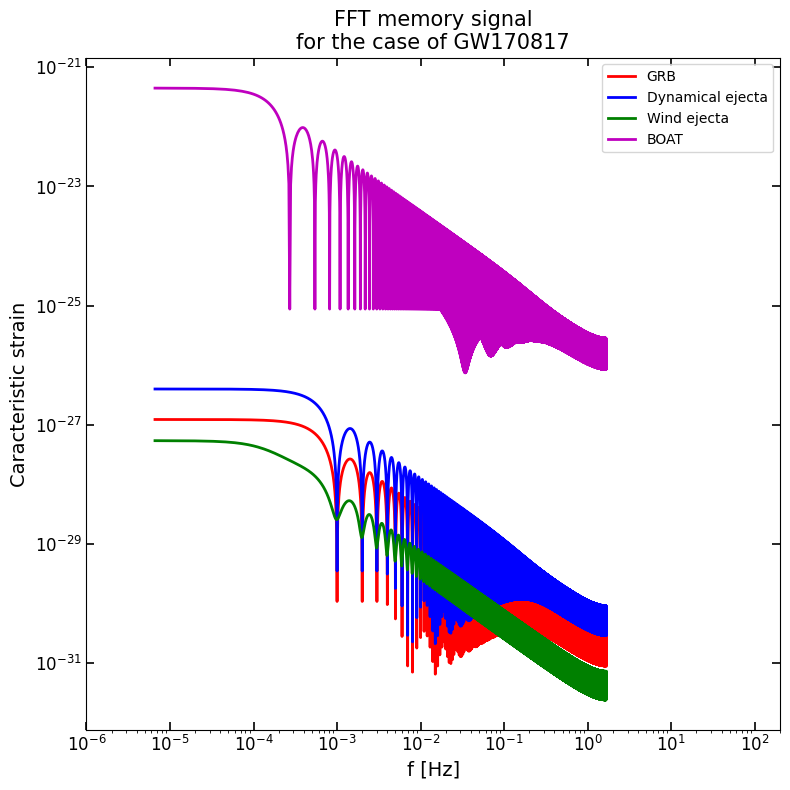

In [15]:
# Let's generate different GRB memory and dynamical/wind ejecta memory

t = np.linspace(-1., 150., 500000) * 1e3  # ms

E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000  
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 100  * 1e6  
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3


h_grb = up.phenom_memory_GRB(
    t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=False)
h_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, r, start_dyn, end_dyn, model='exponential')
h_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_ms, r, start_wind, end_wind, model='exponential')

# FFT plot
h_list = [h_grb, h_dyn, h_wind, h_boat]
labels = ['GRB', 'Dynamical ejecta', 'Wind ejecta', 'BOAT']
up.memory_fft_phenom(t, h_list, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817')



Now applying a window

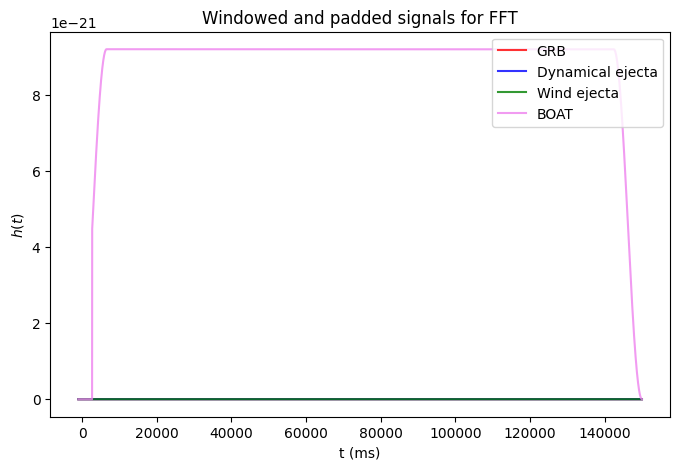

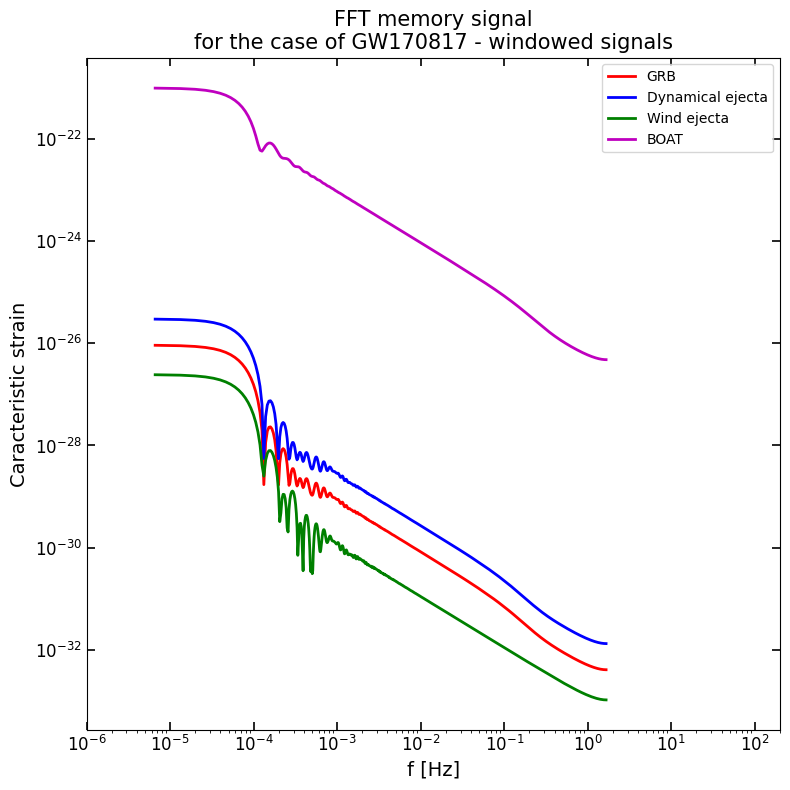

In [16]:
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
plt.figure(figsize=(8, 5))
for idx, h in enumerate(h_list):
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)
    plt.plot(t, h_w, label=labels[idx],c = colors[idx], alpha=0.8)
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("Windowed and padded signals for FFT")
plt.legend(loc= 'upper right')
plt.show()

up.memory_fft_phenom(t, h_windowed, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817 - windowed signals')


LISA sensitivity curve found on https://github.com/eXtremeGravityInstitute/LISA_Sensitivity and associated paper https://arxiv.org/pdf/1803.01944

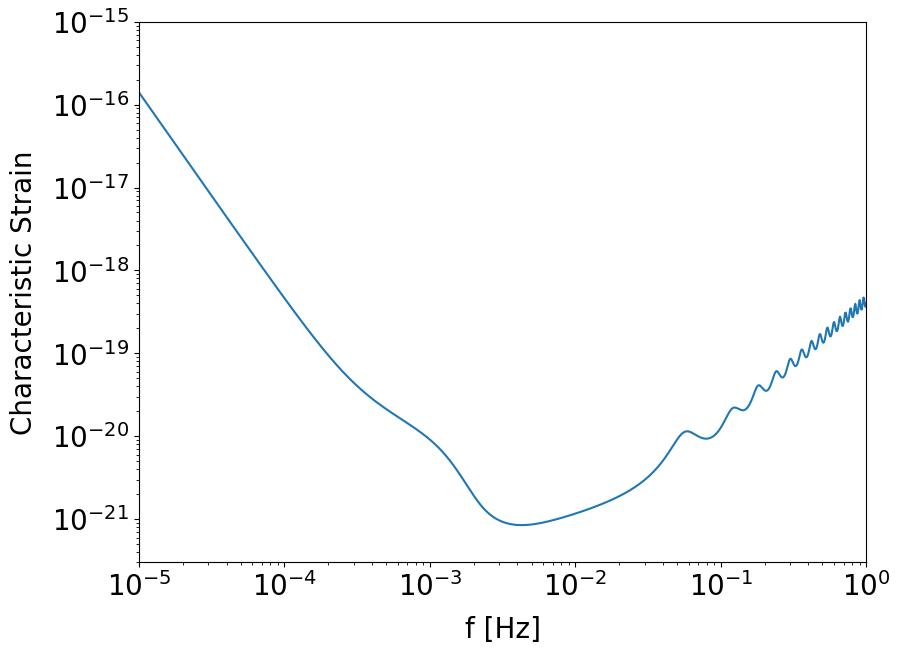

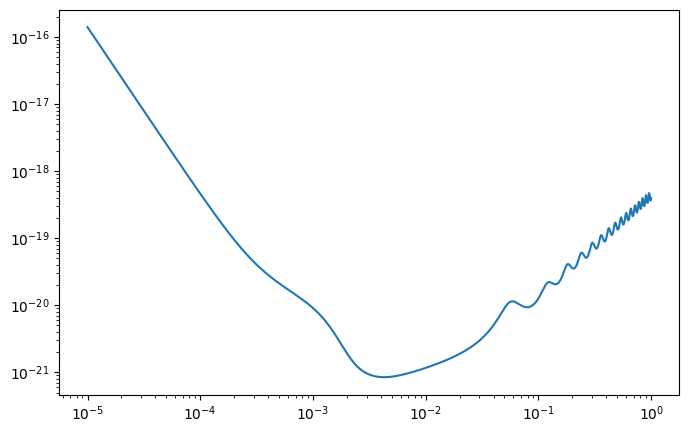

In [17]:
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)
# Plot with the function from LISA module
li.PlotSensitivityCurve(f, Sn)
# Or we can do it ourselves - The same way as in the LISA.py
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, np.sqrt(f*Sn))

Now we add the sensitivity curve and check if the memory signal is above the sensitivity curve of LISA. for the case of 170817

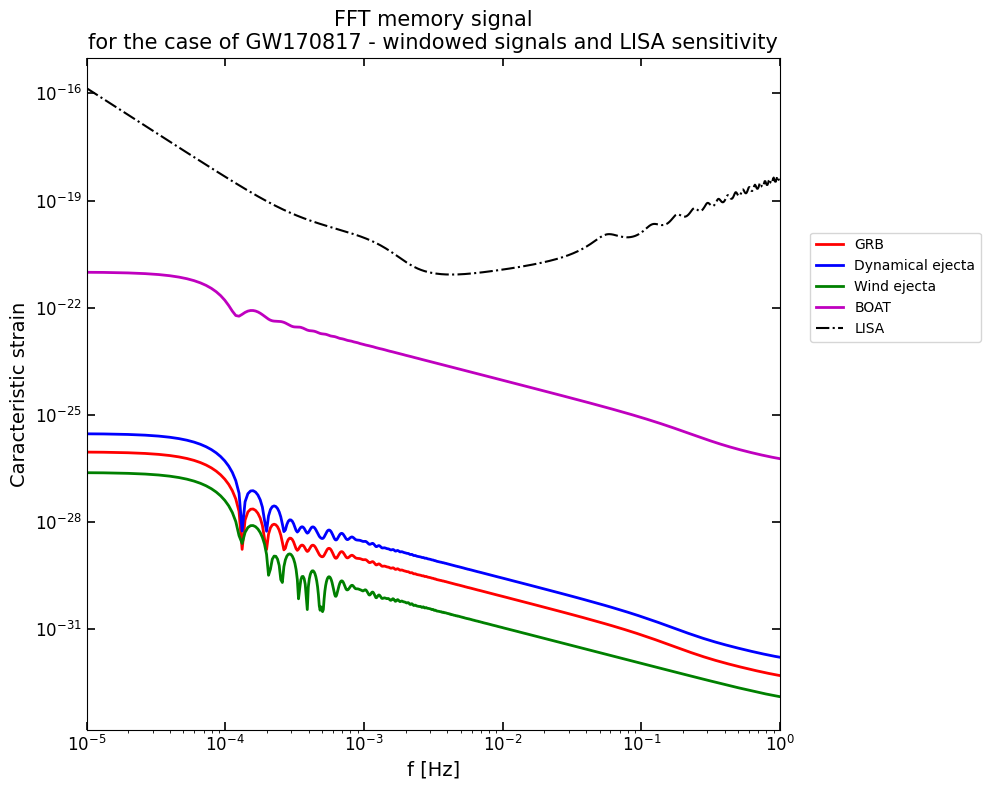

In [18]:
# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

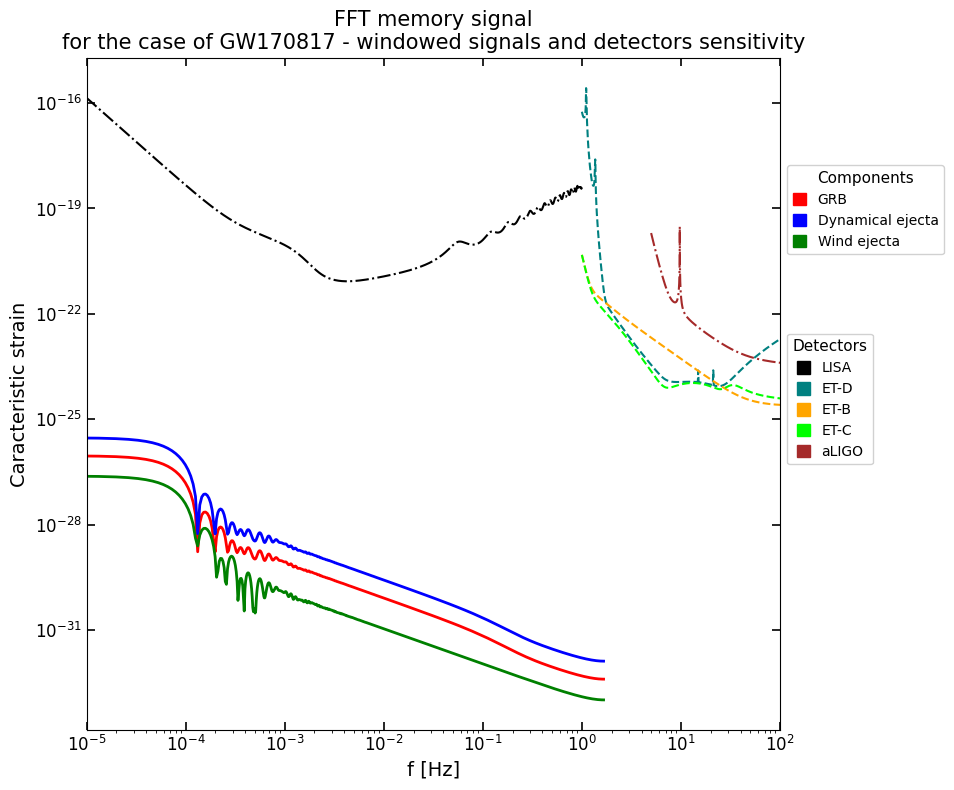

In [19]:
h_list = [h_grb, h_dyn, h_wind]
labels = ['GRB', 'Dynamical ejecta', 'Wind ejecta', 'LISA sensitivity']


# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and detectors sensitivity',
    return_fig=True
)
# ---
# HERE IT IS NEW 
# ---
# Remove the legend to make a new one
ax.get_legend().remove()

# handles for the components represented by a square in the legend
import matplotlib.patches as mpatches

# Créer les handles pour les composantes avec des carrés (patches)
component_handles = [
    mpatches.Patch(color='r', label='GRB'),
    mpatches.Patch(color='b', label='Dynamical ejecta'),
    mpatches.Patch(color='g', label='Wind ejecta')
]

# LISA
ax.loglog(f, np.sqrt(f*Sn), color='k', linestyle='-.', linewidth=1.5)

# ET sensitivity curves for 3 configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}
et_colors = {'ET-D': 'teal', 'ET-B': 'orange', 'ET-C': 'lime'}
for label, data in et_sensitivities.items():
    ax.loglog(data[:, 0], data[:, 1], linestyle='--', color=et_colors[label], linewidth=1.5)

# aLIGO sensitivity curve
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1], linestyle='-.', color='brown', linewidth=1.5)

# handles for the detectors
detector_handles = [
    mpatches.Patch(color='k', label='LISA'),
    mpatches.Patch(color='teal', label='ET-D'),
    mpatches.Patch(color='orange', label='ET-B'),
    mpatches.Patch(color='lime', label='ET-C'),
    mpatches.Patch(color='brown', label='aLIGO')
]
# First one for the components

# Second for the detectors
legend1 = ax.legend(handles=detector_handles, loc='upper left',
                   bbox_to_anchor=(1., 0.6), title='Detectors',
                   fontsize=10, title_fontsize=11, framealpha=0.9,
                    handlelength=1.0, handleheight=1.0)

ax.add_artist(legend1)

legend2 = ax.legend(handles=component_handles, loc='upper left', 
                   bbox_to_anchor=(1., 0.85), title='Components',
                   fontsize=10, title_fontsize=11, framealpha=0.9,
                    handlelength=1.0, handleheight=1.0)
ax.set_xlim(1e-5, 1e2)
plt.show()

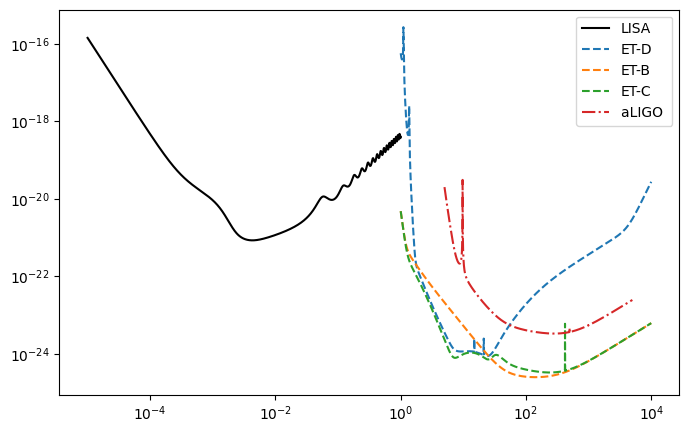

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k')
# ET sensitivity curves for 3 configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}
for label, data in et_sensitivities.items():
    ax.loglog(data[:, 0], data[:, 1], label=label, linestyle='--')
# aLIGO sensitivity curve
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1], label='aLIGO ', linestyle='-.')
ax.legend(loc='upper right')

plt.show()

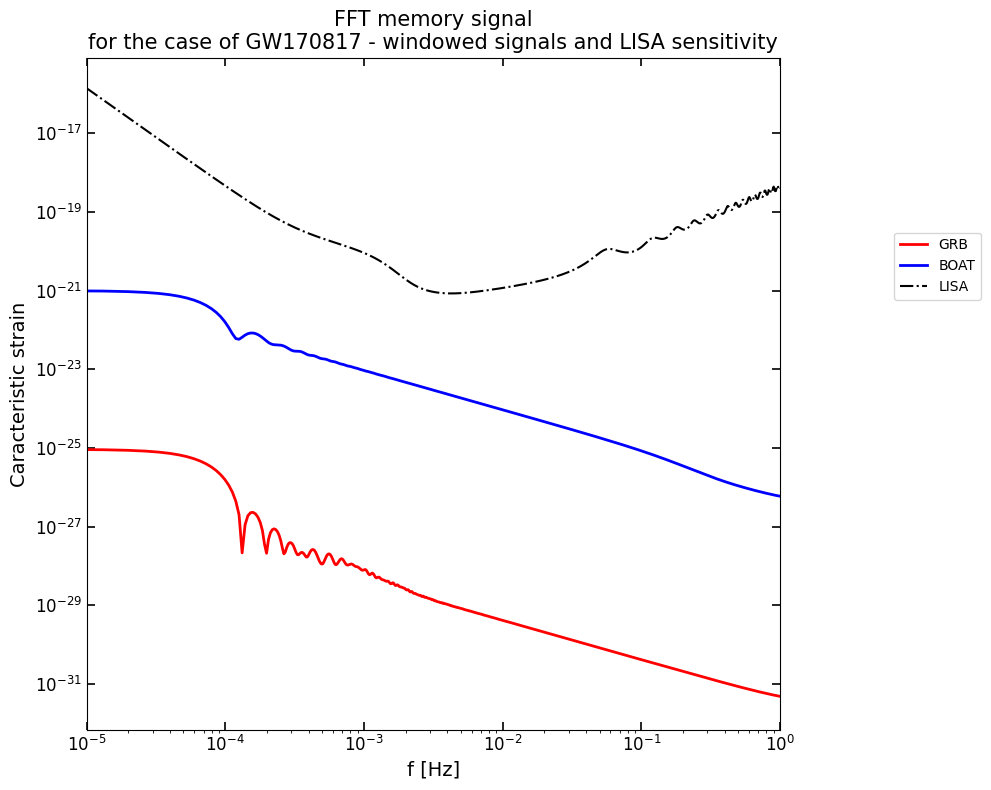

In [21]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms

E_j = 1e51  # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  
beta = 0.99  
tau_grb_ms = 100  # ms
start_grb, end_grb = 0, 30e3 #end at 30s 

h_grb = up.phenom_memory_GRB(t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=False)

h_list = [h_grb, h_boat]
labels = ['GRB', 'BOAT']


# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

Try to reproduce plots of https://arxiv.org/pdf/gr-qc/0405067

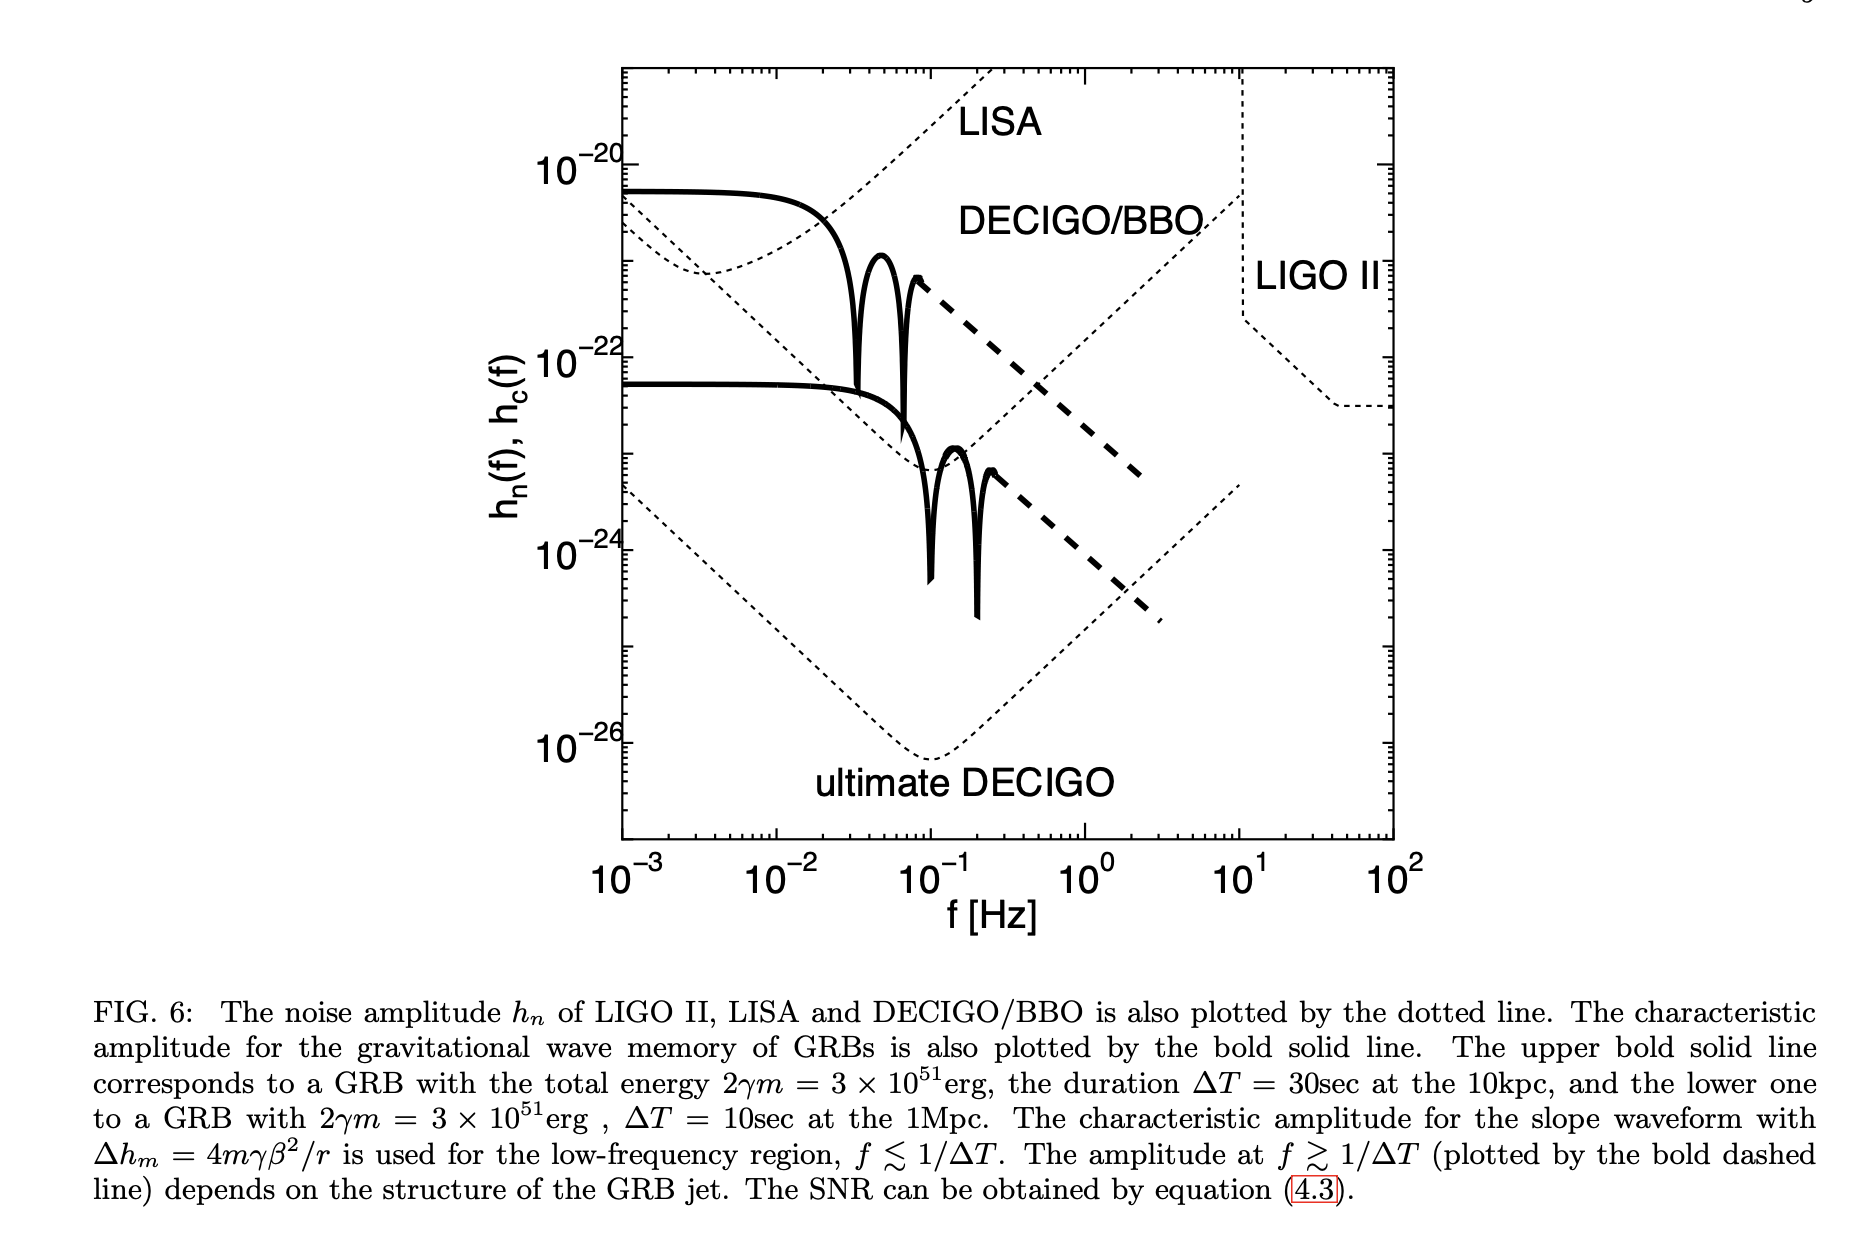

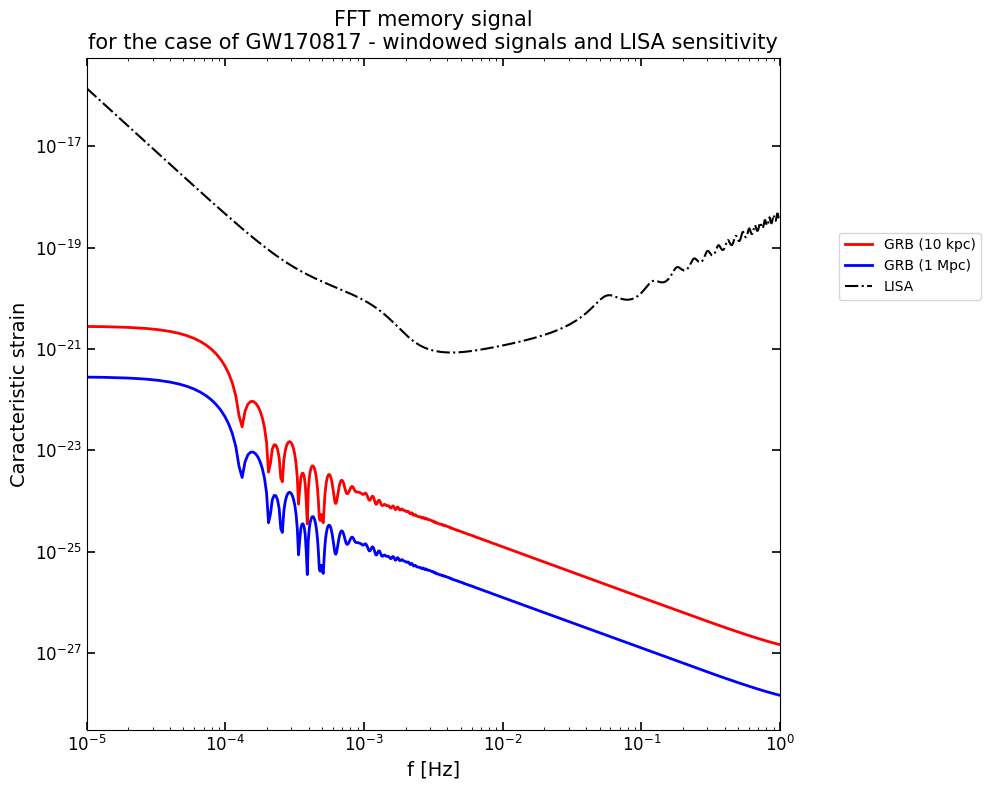

In [22]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms
theta = np.deg2rad(30)
h_grb_1 = up.phenom_memory_GRB(t, 3e51, beta, theta, 10e3, 1e3, start_grb, 30e3, model='exponential', plot=False) # 10 kpc case
h_grb_2 = up.phenom_memory_GRB(t, 3e52, beta, theta, 1e6, 1e3, start_grb, 10e3, model='exponential', plot=False) # 1 Mpc case

h_list = [h_grb_1, h_grb_2]
labels = ['GRB (10 kpc)', 'GRB (1 Mpc)']
# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g']
for idx, h in enumerate(h_list): 
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)
    
# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.tick_params(axis='both', labelsize=12, which='both', direction='in', top=True, right=True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

## Test of a new formula for the FFT of the memory signal based on formula (4.2) provided by https://arxiv.org/pdf/gr-qc/0405067

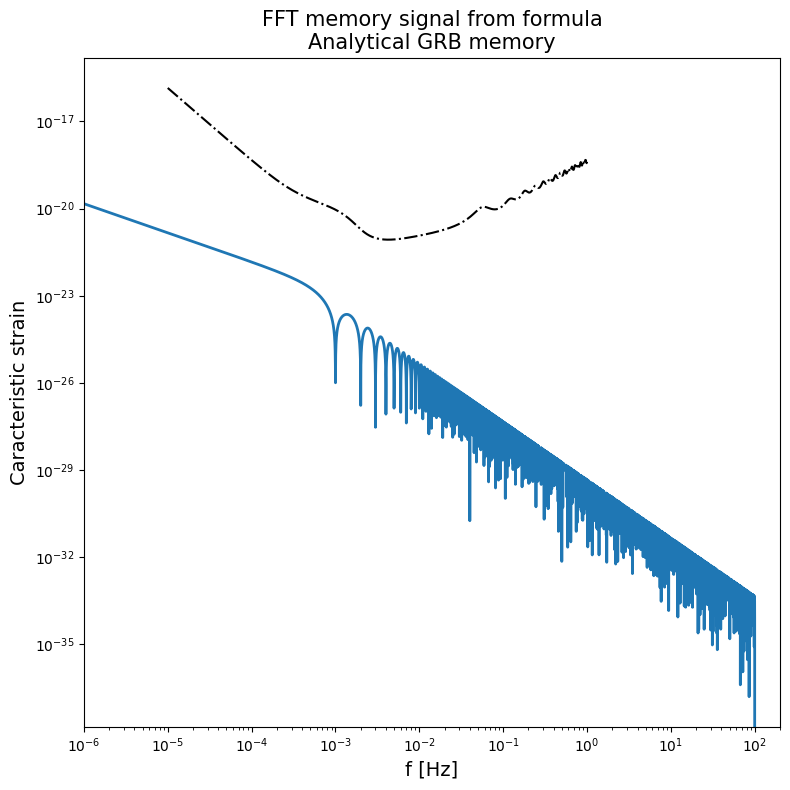

In [23]:
E_j = 1e50   
beta = 0.99
theta = np.deg2rad(30)
r = 100 * 1e6 # 100 Mpc
delta_h_grb = up.delta_h_GRB(E_j, beta, theta, r)
tau_grb = 1e3  # ms
_,_=up.memory_fft_formula(
    delta_h_grb, tau_grb, plot=True, show=True, add_info_title='Analytical GRB memory', LISA= True)


Now we can compare with my method for the 2 cases mentioned above

<Figure size 800x800 with 0 Axes>

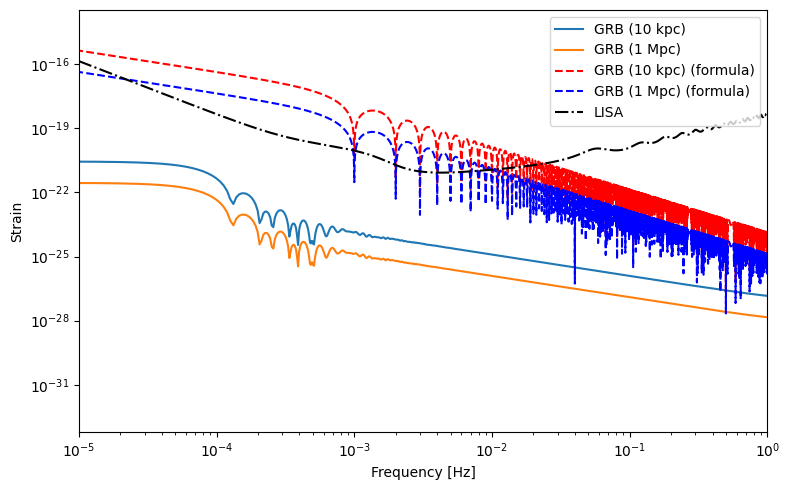

In [24]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms
theta = np.deg2rad(30)
E_1, E_2 = 3e51, 3e52
beta = 0.99
tau_grb_ms = 1e3
r_1, r_2 = 10e3, 1e6
start_grb = 0
end_1, end_2 = 30e3, 10e3
h_list =[]
# Compute the memory amplitude for both cases
delta_h_1 = up.delta_h_GRB(E_1, beta, theta, r_1)
delta_h_2 = up.delta_h_GRB(E_2, beta, theta, r_2)

# Compute GRB memory signals for two cases
h_grb_1 = up.phenom_memory_GRB(t, E_1, beta, theta, r_1, tau_grb_ms, start_grb, end_1, model='exponential', plot=False)
h_grb_2 = up.phenom_memory_GRB(t, E_2, beta, theta, r_2, tau_grb_ms, start_grb, end_2, model='exponential', plot=False)

# Apply Tukey window
h_windowed = [
    using.apply_window(h_grb_1, window_type='tukey', alpha=0.1),
    using.apply_window(h_grb_2, window_type='tukey', alpha=0.1)
]
labels = ['GRB (10 kpc)', 'GRB (1 Mpc)']
colors = ['r', 'b']

# Compute FFT for windowed signals
results = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=False, show=False, return_fft=True
)

# Analytical FFTs
freq_1, fft_1 = up.memory_fft_formula(delta_h_1, tau_grb_ms, plot=False, show=False)
freq_2, fft_2 = up.memory_fft_formula(delta_h_2, tau_grb_ms, plot=False, show=False)

# Final plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (freq, fft) in enumerate(results):
    plt.plot(freq, fft, label=labels[i])
ax.loglog(freq_1, np.abs(fft_1), label=f'{labels[0]} (formula)', color=colors[0], linestyle='--')
ax.loglog(freq_2, np.abs(fft_2), label=f'{labels[1]} (formula)', color=colors[1], linestyle='--')
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax.legend(loc='upper right')
ax.set_xlim(1e-5, 1)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain')
plt.tight_layout()
plt.show()